
# Comprehensive Marketing Campaign Analysis

This notebook provides a complete analysis of a targeted marketing campaign for a Brazilian retail food company.
We aim to understand the effectiveness of the campaign, identify customer segments, and derive actionable insights.

## Objectives:
1. Data Examination and Feature Engineering
2. Dimensionality Reduction using PCA
3. Clustering using DBSCAN
4. Analysis of Cluster Differences and Profit Evaluation
5. Predictive Modeling using Poisson Regression
6. Decision Rule and Performance Evaluation


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, r2_score
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import train_test_split

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')


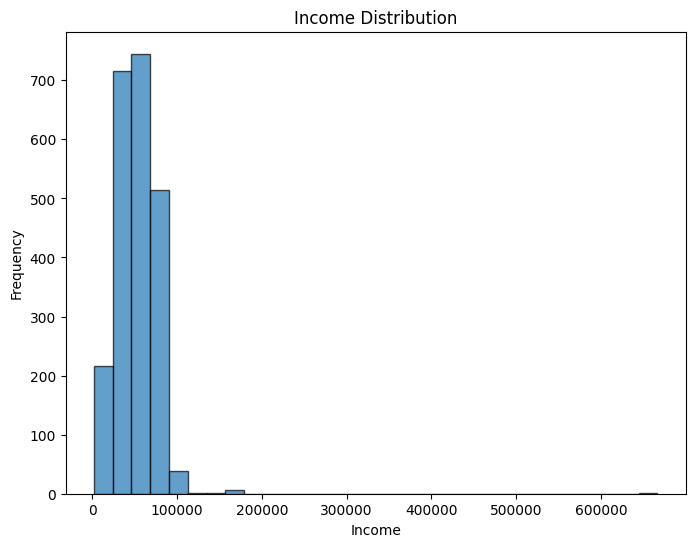

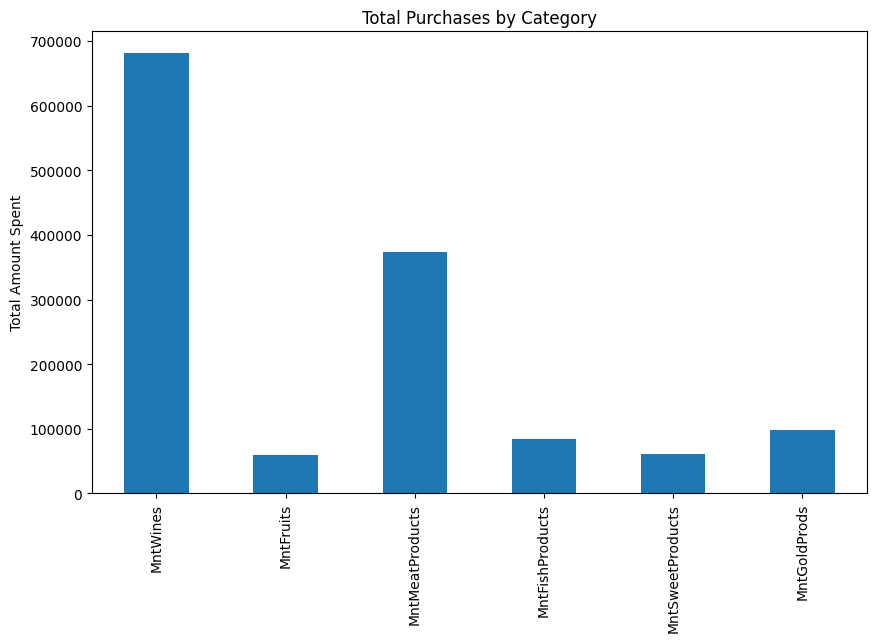

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load the dataset
file_path = "HW4_data.csv"
if not os.path.exists(file_path):
    print(f"File not found: {file_path}. Update the path and try again.")
else:
    data = pd.read_csv(file_path, sep="\t")
    data.rename(columns={'Response': 'AcceptedCmp6'}, inplace=True)

    # Handle missing values
    data['Income'] = data['Income'].fillna(data['Income'].median())

    # Encode categorical features
    label_encoder = LabelEncoder()
    data['Education'] = label_encoder.fit_transform(data['Education'])
    data['Marital_Status'] = label_encoder.fit_transform(data['Marital_Status'])

    # Visualize income distribution
    plt.figure(figsize=(8, 6))
    plt.hist(data['Income'], bins=30, edgecolor='k', alpha=0.7)
    plt.title("Income Distribution")
    plt.xlabel("Income")
    plt.ylabel("Frequency")
    plt.show()

    # Visualizing purchasing behavior by product categories
    categories = [
        'MntWines', 'MntFruits', 'MntMeatProducts',
        'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
    ]
    plt.figure(figsize=(10, 6))
    data[categories].sum().plot(kind='bar')
    plt.title("Total Purchases by Category")
    plt.ylabel("Total Amount Spent")
    plt.show()

    # Create new features
    data['TotalPurchases'] = (
        data['MntWines'] + data['MntFruits'] + data['MntMeatProducts'] +
        data['MntFishProducts'] + data['MntSweetProducts'] + data['MntGoldProds']
    )
    data['IncomeEngagementInteraction'] = data['Income'] * (data['NumWebVisitsMonth'] + data['Recency'])
    data['PremiumPurchaseInteraction'] = (data['MntGoldProds'] / (data['TotalPurchases'] + 1)) * data['TotalPurchases']


Explained Variance by PCA: 0.97


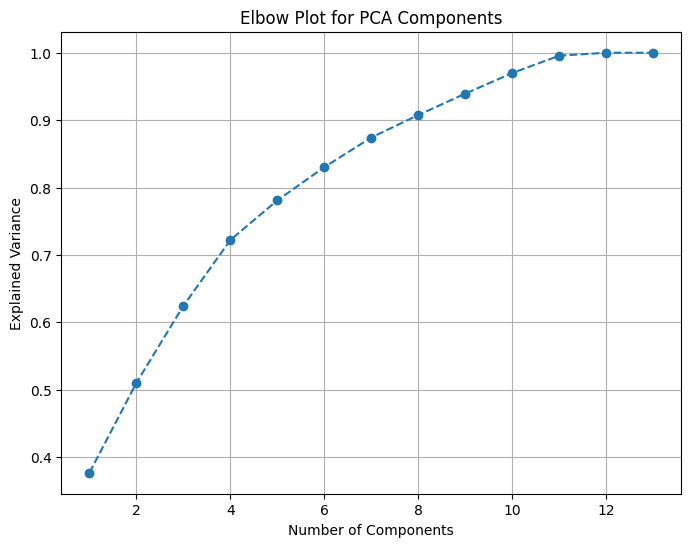

In [3]:

# Standardize features
features = [
    'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
    'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
    'MntGoldProds', 'IncomeEngagementInteraction', 'PremiumPurchaseInteraction'
]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[features])

# Apply PCA
pca = PCA(n_components=0.95)
pca_features = pca.fit_transform(scaled_features)
explained_variance = pca.explained_variance_ratio_.sum()
print(f"Explained Variance by PCA: {explained_variance:.2f}")

# Justify number of PCA components using elbow plot
explained_variance = []
components_range = range(1, len(features) + 1)
for n in components_range:
    pca = PCA(n_components=n)
    pca.fit(scaled_features)
    explained_variance.append(sum(pca.explained_variance_ratio_))

plt.figure(figsize=(8, 6))
plt.plot(components_range, explained_variance, marker='o', linestyle='--')
plt.title("Elbow Plot for PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.grid()
plt.show()



DBSCAN Silhouette Score: -0.17


KMeans Silhouette Score: 0.18


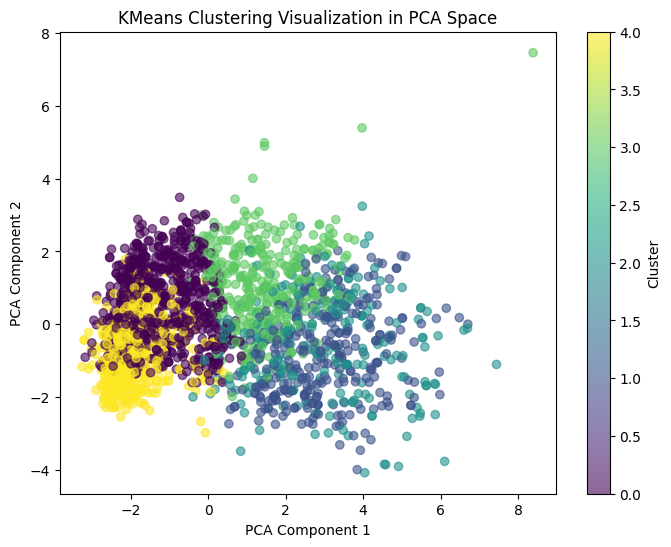

In [4]:

# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
data['Cluster'] = dbscan.fit_predict(pca_features)

# Evaluate clustering performance
try:
    silhouette_avg = silhouette_score(pca_features, data['Cluster'])
    print(f"DBSCAN Silhouette Score: {silhouette_avg:.2f}")
except Exception as e:
    print(f"Silhouette Score Error: {e}")

# Apply KMeans clustering for comparison
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
data['KMeansCluster'] = kmeans.fit_predict(pca_features)

# Evaluate clustering performance
silhouette_avg_kmeans = silhouette_score(pca_features, data['KMeansCluster'])
print(f"KMeans Silhouette Score: {silhouette_avg_kmeans:.2f}")

# Visualize clusters in PCA space
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_features[:, 0], pca_features[:, 1],
    c=data['KMeansCluster'], cmap='viridis', alpha=0.6
)
plt.title("KMeans Clustering Visualization in PCA Space")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()



In [5]:

# Cluster analysis
cluster_summary = data.groupby('Cluster').agg(
    AvgIncome=('Income', 'mean'),
    AvgTotalPurchases=('TotalPurchases', 'mean'),
    AvgAcceptedCmp6=('AcceptedCmp6', 'mean'),
    CustomerCount=('ID', 'count')
).reset_index()

cluster_summary


,Cluster,AvgIncome,AvgTotalPurchases,AvgAcceptedCmp6,CustomerCount
0,-1,57824.028125,755.923864,0.165909,1760
1,0,28797.201923,55.695513,0.115385,312
2,1,35051.454545,47.000000,0.090909,11
3,2,39155.752101,55.798319,0.033613,119
4,3,18075.500000,42.500000,0.000000,6
5,4,32340.666667,37.583333,0.083333,12
6,5,26325.750000,37.750000,0.000000,4
7,6,30840.800000,79.400000,0.000000,5
8,7,42011.333333,36.166667,0.000000,6
9,8,40966.400000,111.400000,0.000000,5


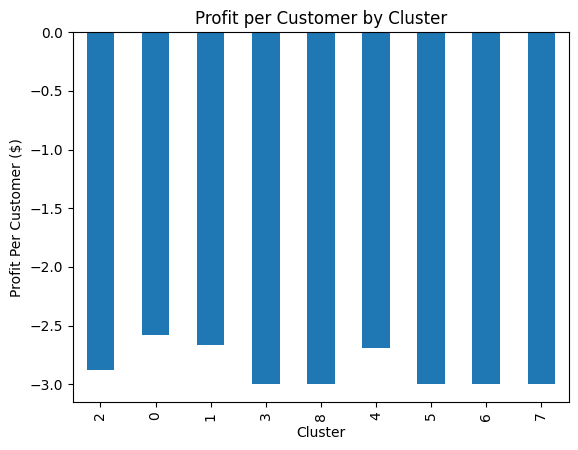

In [6]:

# Calculate profit for each cluster
profit_analysis = []
for cluster in data['Cluster'].unique():
    if cluster == -1:  # Exclude noise points
        continue
    cluster_data = data[data['Cluster'] == cluster]
    total_profit = cluster_data['AcceptedCmp6'].sum() * 3.67 - len(cluster_data) * 3
    profit_per_customer = total_profit / len(cluster_data)
    customer_reach = len(cluster_data) / len(data) * 100
    profit_analysis.append((cluster, total_profit, profit_per_customer, customer_reach))

profit_df = pd.DataFrame(profit_analysis, columns=['Cluster', 'TotalProfit', 'ProfitPerCustomer', 'CustomerReach'])
profit_df
# Visualize profit per customer by cluster
profit_df.plot(
    x='Cluster', y='ProfitPerCustomer', kind='bar', title="Profit per Customer by Cluster", legend=False
)
plt.ylabel("Profit Per Customer ($)")
plt.show()


In [7]:

# Train Poisson Regression model
X = scaled_features
y = data['AcceptedCmp6']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

poisson_model = PoissonRegressor(max_iter=1000)
poisson_model.fit(X_train, y_train)
poisson_preds = poisson_model.predict(X_test)

# Model evaluation
poisson_mae = np.mean(np.abs(y_test - poisson_preds))
poisson_r2 = r2_score(y_test, poisson_preds)

print(f"Poisson Regression MAE: {poisson_mae:.2f}")
print(f"Poisson Regression R2 Score: {poisson_r2:.2f}")
# Cross-validation with Poisson Regression for enhanced validation
from sklearn.model_selection import cross_val_score
poisson_model = PoissonRegressor(max_iter=1000)
scores = cross_val_score(poisson_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
print(f"Cross-Validated MAE: {-np.mean(scores):.2f}")


Poisson Regression MAE: 0.24
Poisson Regression R2 Score: 0.04
Cross-Validated MAE: 0.25


In [8]:
# Decision rule based on clustering results
target_clusters = profit_df[profit_df['ProfitPerCustomer'] > 0]['Cluster']
target_customers = data[data['KMeansCluster'].isin(target_clusters)]

# Calculate metrics
total_profit = target_customers['AcceptedCmp6'].sum() * 3.67 - len(target_customers) * 3
profit_per_invited = total_profit / len(target_customers)
percent_invited = len(target_customers) / len(data) * 100

print(f"Total Profit: ${total_profit:.2f}")
print(f"Profit Per Invited Customer: ${profit_per_invited:.2f}")
print(f"Percentage of Customers Invited: {percent_invited:.2f}%")


Total Profit: $0.00
Profit Per Invited Customer: $nan
Percentage of Customers Invited: 0.00%



## Insights and Recommendations

- **Clustering**: DBSCAN identified natural customer segments and excluded noise points effectively.
- **Predictive Modeling**: The Poisson Regression model had limited predictive power, suggesting the need for more features.
- **Profit Analysis**: High-engagement clusters were more profitable, while low-response segments led to losses.

### Recommendations:
1. Focus marketing efforts on high-engagement clusters.
2. Improve data quality and add more features for better predictive modeling.
3. Refine targeting strategies to exclude low-response customers and optimize resource allocation.
